In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import numpy as np
from tqdm.auto import tqdm
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp

In [2]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.254"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_sg_int4_v2 - envelope memory 16384 samples (38.095 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 3

In [3]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12\Loop'

# Connect yoko

In [288]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91WB18861'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)

True

In [ ]:
flux1 = 4.938
flux2 = 4.351
Yoko_current = 4.351 # [mA]
yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=10e-6)

0.004351

# System config

In [4]:
r1 = 5352.79
r2 = 5494.19
r3 = 5667.69
r4 = 5796.46
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]
res_mixer = round(np.sum(r)/6)
res_mixer=5800
q1, q2, q3, q4, q5, q6 = [2, 0, 1, 7, 0, 14]
q = [q1, q2, q3, q4, q5, q6]

In [5]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': r,
          'mixer_freq': res_mixer,
          'res_gains': [0.5]*6,
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 2,
          'ro_len': 2,
          'relax_delay':50
         }

qb_cfg={
    'qb_ch':q,
    'f_q': 4200,
    'qmixer_freq': 4200,
    'q_len':5,
    'q_gain': 0.01,
    'sigma': 0.5,
}

config = {**config, **qb_cfg}

  0%|          | 0/1000 [00:00<?, ?it/s]

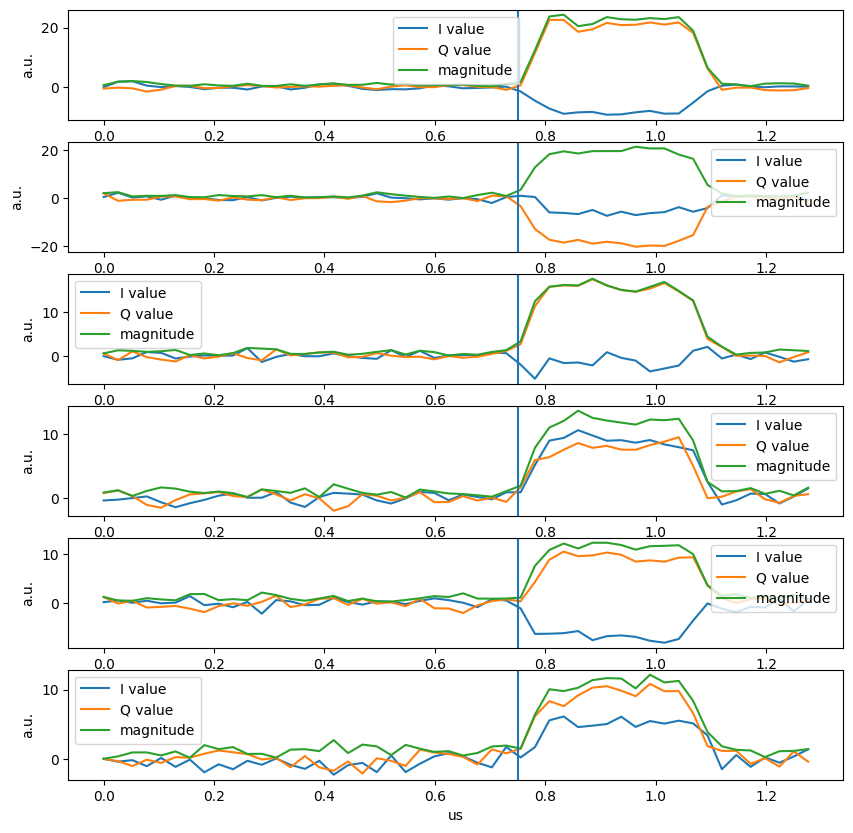

In [775]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':1.3, 
    'res_gains': [1.0]*6, 
    'res_freqs':np.array(r)-15, 
    'trig_time': 0}) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, soft_avgs=1000)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# for i, ch in enumerate(config['ro_chs']):
#     # frequency-matching cross-check
#     f_gen = prog.res_chs[config['res_ch']]['mux_tones'][i]['freq_rounded']
#     f_ro = prog.ro_chs[ch]['ro_config']['f_rounded']
#     print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

# Mux OneTone

In [6]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [148]:
n_roch = 6
F_Span = 20
F_Steps = 81

sweep = np.linspace(-F_Span, F_Span, F_Steps)
z_list = [[] for _ in range(6)]  
config['res_gains'] = [0.3] * n_roch

for i in tqdm(sweep):
    config['res_freqs'] = np.array(r) + i
    prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=config)
    results = prog.acquire(soc, soft_avgs=50, progress=False)
    
    for idx, res in enumerate(results):
        z_list[idx].append(res[0][0] + 1j * res[0][1])

  0%|          | 0/81 [00:00<?, ?it/s]

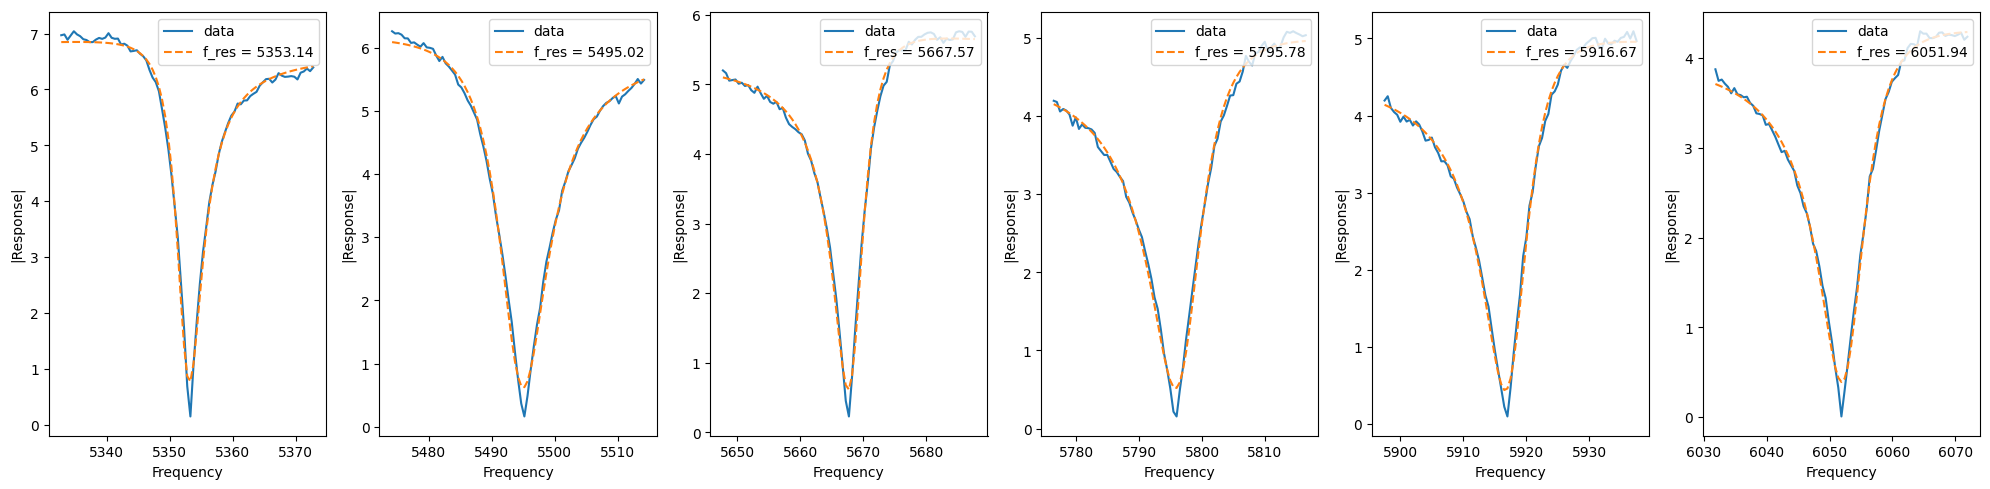

In [149]:
popt = [[] for _ in range(n_roch)]
fit_res = [[]] * n_roch


fig, ax = plt.subplots(1, n_roch, figsize=(20,5))

for i in range(n_roch):
    freq_sweep = r[i] + sweep
    mag_response = np.abs(z_list[i])

    ax[i].plot(freq_sweep, mag_response, label='data')
    popt[i], _ = fit_asym_lor(freq_sweep, mag_response)
    ax[i].plot(freq_sweep, asym_lorfunc(freq_sweep, *popt[i]), '--', label=f'f_res = {popt[i][2]:.2f}')
    ax[i].legend(loc='upper right')
    ax[i].set_xlabel('Frequency')
    ax[i].set_ylabel('|Response|')
    fit_res[i] = round(popt[i][2], 2)

plt.tight_layout()
plt.show()

In [ ]:
data_path = data_path

for idx in range(n_roch):
        exp_name = f"res onetone mux r{idx}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + sweep)*1e6},  

                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(x[idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Punchout

In [ ]:
class MuxPunchout(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0, 1, 2, 3, 4, 5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)


In [ ]:
n_roch=6
F_Sapn = 20
F_Steps = 51

G_Start = 0.02
G_Stop = 1
G_Steps = 51
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
gain = np.linspace(G_Start, G_Stop, G_Steps)  

outer_loop = tqdm(gain, desc="Gain Sweep")
z = [] 
for g in outer_loop:
    config['res_gains'] = [g] * n_roch
    amps = []  

    for f in (fpts):
        config['res_freqs'] = np.array(r) + f
        prog = MuxPunchout(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)
    z.append(np.array(amps))
z = np.array(z)  


Gain Sweep: 100%|██████████| 51/51 [06:53<00:00,  8.10s/it]


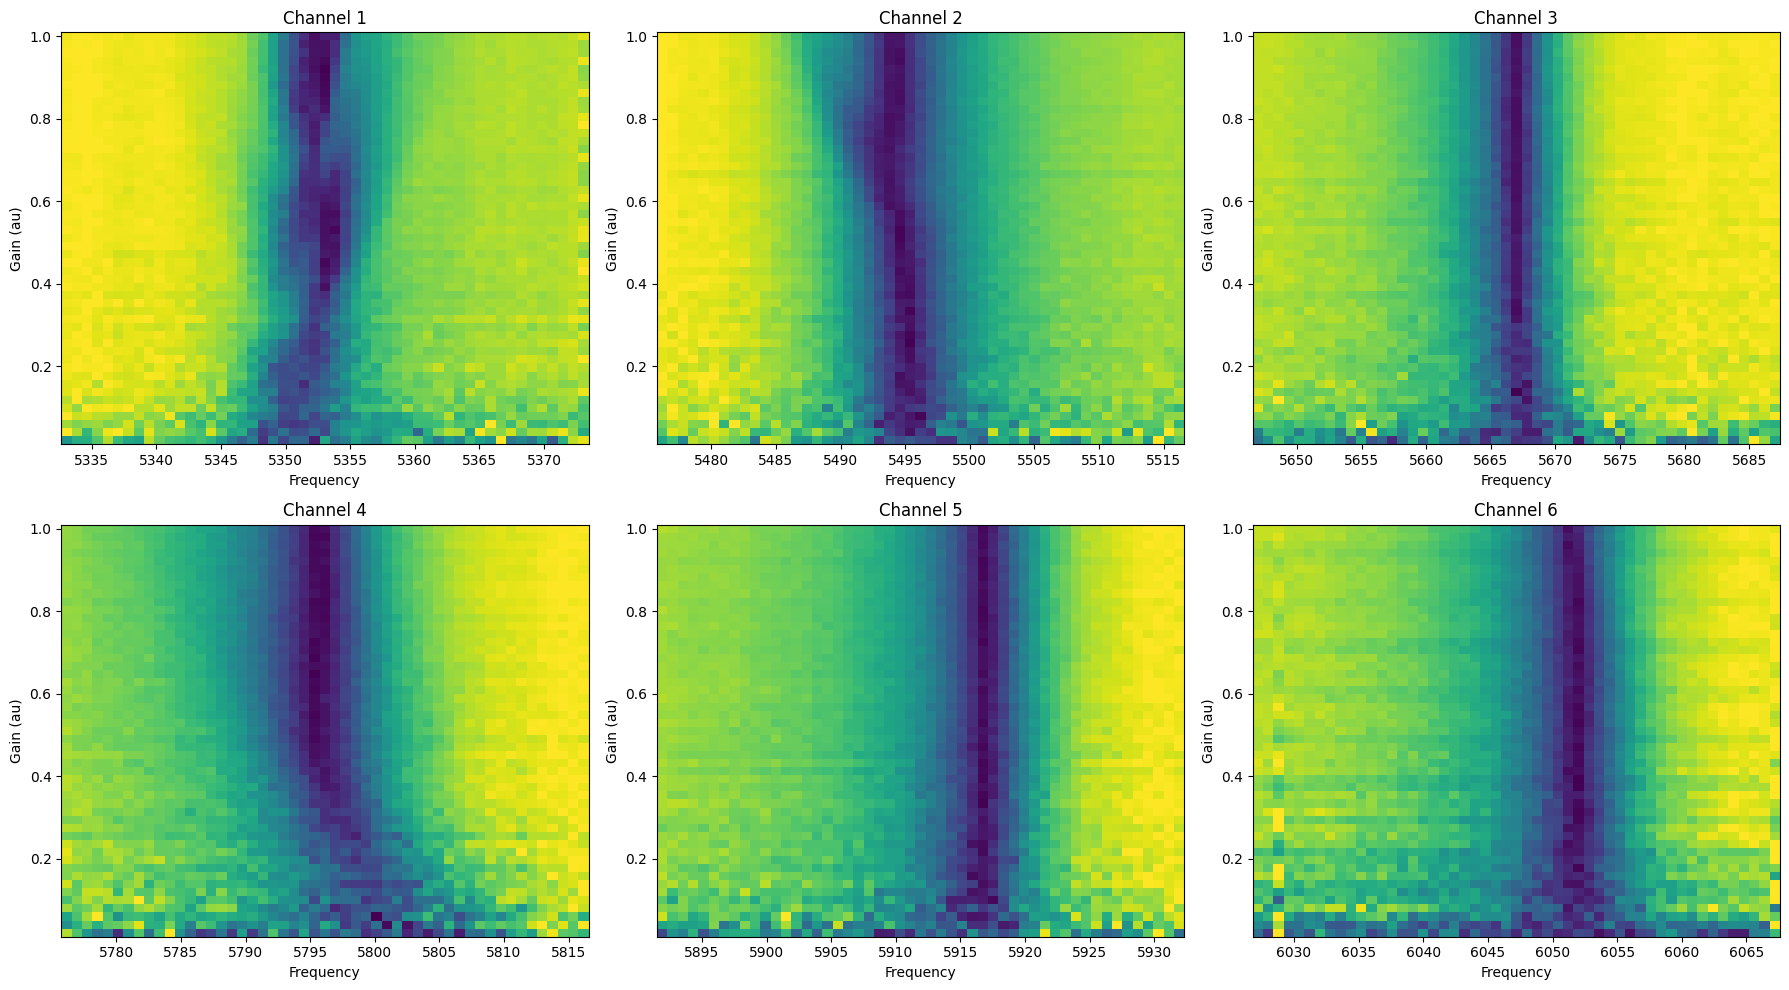

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    data = np.abs(z[:, :, idx]) 
    norm_data = np.zeros_like(data)
    for i in range(data.shape[0]):  
        max_val = np.max(data[i])
        if max_val != 0:
            norm_data[i] = data[i] / max_val  
        else:
            norm_data[i] = data[i]  
    pcm = axes[idx].pcolormesh(r[idx] + fpts, gain, norm_data, shading='auto')
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()

In [ ]:
data_path = data_path

for idx in range(6):
        exp_name = f"res pdr mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + fpts)*1e6},  
                y_info={'name': 'DAC Gain', 'unit': "a.u",
                        'values': gain},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Flux

In [ ]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [278]:
n_roch = 6

F_Sapn = 15
F_Steps = 51

Curr_Start = 6
Curr_Stop = -2
Curr_Step = 161
config['res_gains'] = [0.2] * n_roch
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
flux = np.linspace(Curr_Start, Curr_Stop, Curr_Step) * 1e-3

z = []

outer_loop = tqdm(flux, desc="Flux Sweep")

for curr in outer_loop:
    yoko_global.setValue(sQuant='Current', value=curr, rate=50e-6)

    amp_per_flux = []

    inner_loop = tqdm(total=len(sweep), desc=f"Freq Sweep (Flux={curr*1e3:.2f} mA)", leave=False)

    for i in sweep:
        config['res_freqs'] = np.array(r) + i
        prog = MuxOneTone(soccfg, reps=100, final_delay=0.1, cfg=config)
        results = prog.acquire(soc, soft_avgs=20, progress=False)

        amp_per_freq = []

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amp_per_flux.append(amp_per_freq)

    inner_loop.close()

    z.append(np.array(amp_per_flux))

z = np.array(z)

Flux Sweep: 100%|██████████| 161/161 [1:03:13<00:00, 23.56s/it]


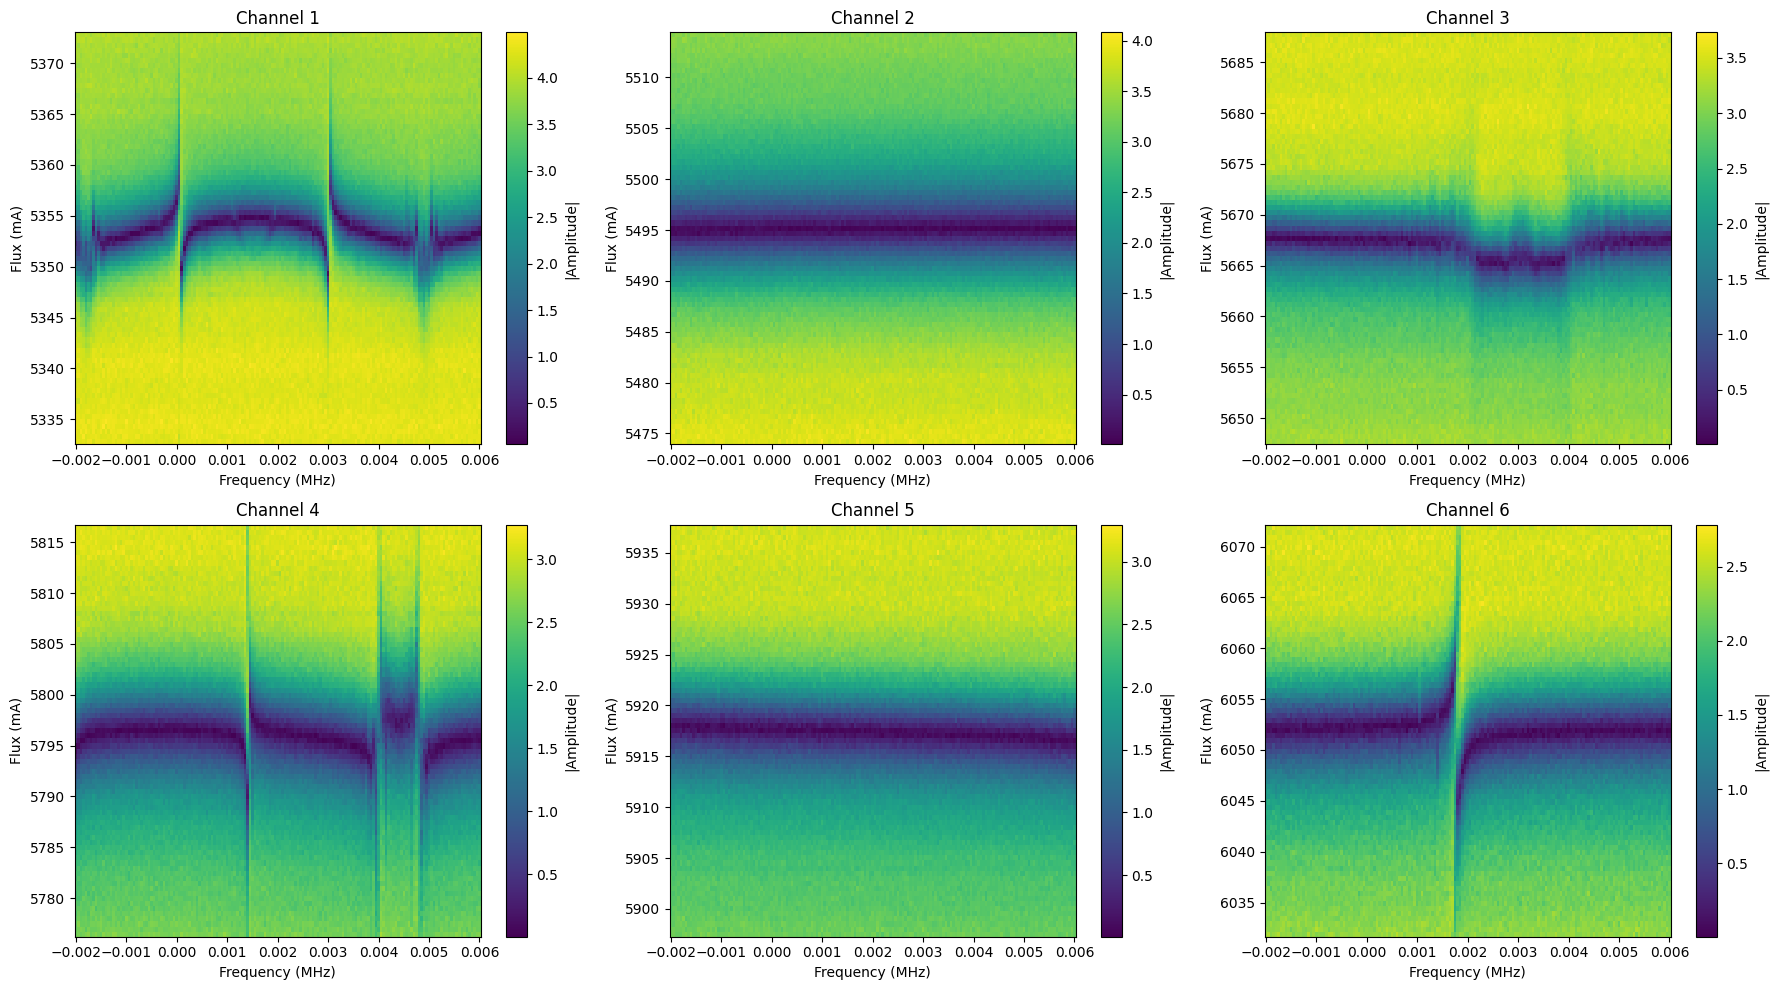

In [279]:
freqs = np.array(r)[:, None] + sweep[None, :]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    pcm = axes[idx].pcolormesh(
        flux, freqs[idx], 
        np.abs(z[:, :, idx]).T,
        shading='auto'
    )
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency (MHz)')
    axes[idx].set_ylabel('Flux (mA)')
    fig.colorbar(pcm, ax=axes[idx], label='|Amplitude|')

plt.tight_layout()
plt.show()


In [280]:
data_path = data_path

for idx in range(6):
        exp_name = f"res flux mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[idx])*1e6},  
                y_info={'name': 'yoko current', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Aiming One resonator

In [ ]:
class MuxOneToneFocus(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)

config = {'res_ch': 12,
          'ro_chs': [2],
          'pulse_freqs': r,
          'mixer_freq': 5750,
          'pulse_gains': [0.15],
          'pulse_phases': [0.0],
          'ro_phases': [0.0],
          'trig_time': 0.7,
          'pulse_len': 1.0,
          'ro_len': 1.2,
         }


100%|██████████| 51/51 [00:05<00:00,  9.53it/s]


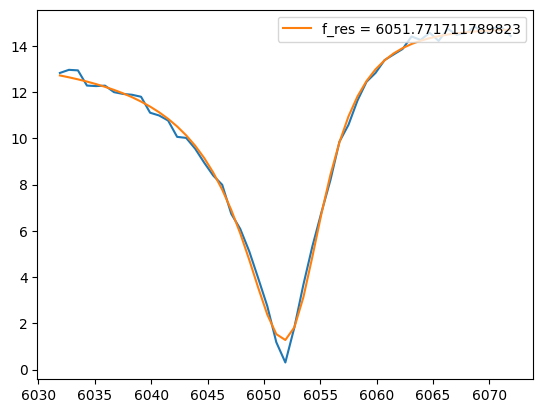

In [ ]:
res_idx = 5

initial = [r[res_idx]]
sweep = np.linspace(-20, 20, 51)
z1=[]

config['pulse_gains'] = [0.15]
for i in tqdm(sweep):
    config['pulse_freqs'] = np.array(initial)+i
    prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.5, cfg=config)
    x1, = prog.acquire(soc, soft_avgs=10, progress=False)
    z1.append(x1[0][0]+1j*x1[0][1])

## Plot ##
plt.plot(initial + sweep, np.abs(z1))
popt,_ = fit_asym_lor(initial + sweep, np.abs(z1))
plt.plot(initial + sweep, asym_lorfunc(initial + sweep, *popt), label=f'f_res = {popt[2]}')
plt.legend(loc='upper right')
res_freq = round(popt[2], 2)

## Punch out

In [ ]:
initial = [r[res_idx]]
sweep_f = np.linspace(-20, 20, 41)  # freq sweep points
sweep_g = np.linspace(0.02, 1, 20)  # gain sweep points


z = [] 

outer_loop = tqdm(sweep_g, desc="Gain Sweep")

for g in outer_loop:
    config['pulse_gains'] = [g] 
    amps = []  

    for f in (sweep_f):
        config['pulse_freqs'] = np.array(initial) + f

        prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)

    z.append(np.array(amps))

z = np.array(z)  # z.shape = (n_gain, n_freq, n_roch)


Gain Sweep: 100%|██████████| 20/20 [01:21<00:00,  4.06s/it]


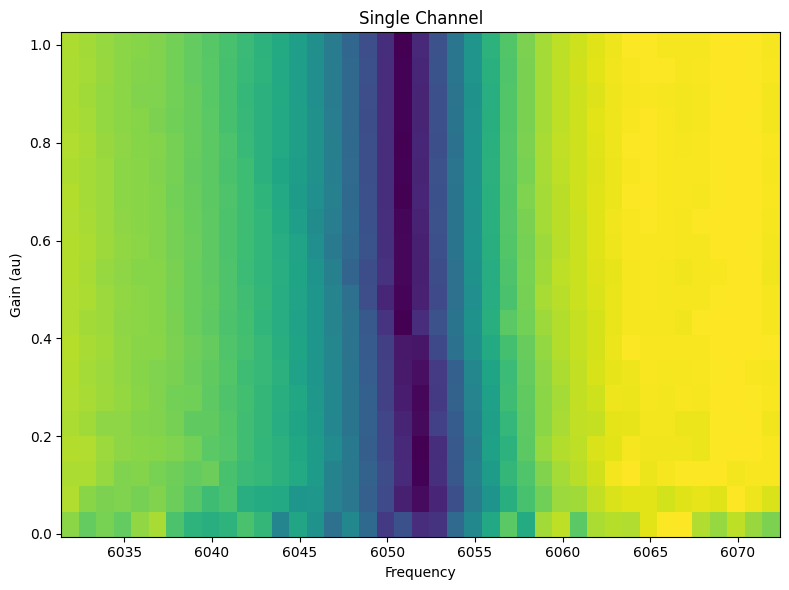

In [ ]:
fpts = sweep_f
gain = sweep_g

fig, ax = plt.subplots(figsize=(8, 6))  


data = np.abs(z[:, :, 0]) 

norm_data = np.zeros_like(data)
for i in range(data.shape[0]):  
    max_val = np.max(data[i])
    if max_val != 0:
        norm_data[i] = data[i] / max_val  
    else:
        norm_data[i] = data[i]

pcm = ax.pcolormesh(np.array(initial) + sweep_f, sweep_g, norm_data, shading='auto')

ax.set_title('Single Channel')
ax.set_xlabel('Frequency')
ax.set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()


In [ ]:
data_path = data_path
exp_name = f"res pdr R{res_idx+1}"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': fpts*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gain},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  z[:, :, 0]},
        comment=f'flux at half flux',
        tag='OneTone'
)

# Mux Two Tone

In [284]:
class MuxTwoTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("floop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="flat_top",
                        envelope=f'ramp{i}',
                        freq=cfg[f'f_q{i+1}'],
                        phase= 0,
                        gain=cfg['q_gain'][i],
                        length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }

span = 500
step = 500

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q1': 2738 + QickSweep1D("floop", -span, span),
    'f_q4': 2935 + QickSweep1D("floop", -span, span),
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': [0.2, 0, 0, 0.2, 0.0, 0.],
    'sigma':0.05
}

run_cfg = {**config, **qb_cfg}


In [285]:
prog = MuxTwoTone(soccfg, reps=100, final_delay=0.1, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=100)
freqs = [[]]*6
for idx in [0,3]:
    freqs[idx]= prog.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)


  0%|          | 0/100 [00:00<?, ?it/s]

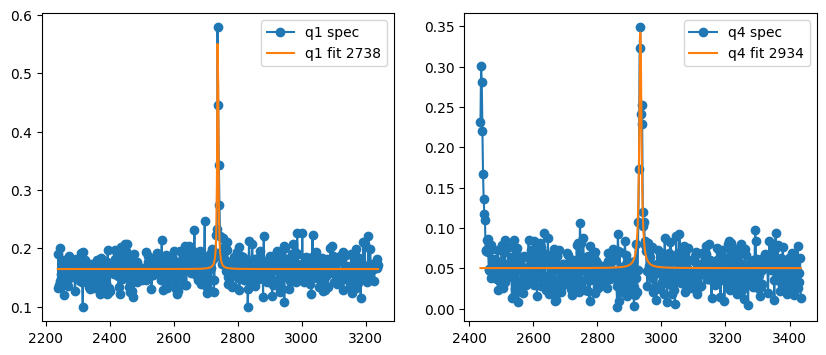

In [286]:
from data_fitting.fitting import lorfunc, fitlor
fig, axes = plt.subplots(1,2, figsize=(10, 4))
axes = axes.flatten()
q_fit=[[]]*6
f_q=[[]]*6
for idx, i in enumerate([0, 3]):
    phase = np.abs(iq_list[i][0].dot([1, 1j]))
    axes[idx].plot(freqs[i], phase, marker='o', label=f'q{i+1} spec')

    q_fit[i], _ = fitlor(freqs[i], phase)

    axes[idx].plot(freqs[i], lorfunc(freqs[i], *q_fit[i]), label=f'q{i+1} fit {q_fit[i][2]:.0f}')
    axes[idx].legend(loc='upper right')
    f_q[i]=q_fit[i][2]

In [789]:
from yamltool import yml_comment
data_path = data_path
run_cfg.pop('f_q1')
run_cfg.pop('f_q4')
config_info = yml_comment(run_cfg)
for idx in [0,3]:
        exp_name = f"qubit mux spec q{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[idx])*1e6},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iq_list[idx][0].dot([1, 1j]))},
                comment=f'{config_info}',
                tag='TwoTone'
        )

## Mux Two channe flux spec

In [289]:

Start_flux = 6 # [mA]
Stop_flux = 4 # [mA]
Steps = 41
### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3


iqlist=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec = MuxTwoTone(soccfg, reps=100, final_delay= 0.01, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=50, progress=False)

    iqlist.append(iq_list)
iqlist = np.array(iqlist)

  0%|          | 0/41 [00:00<?, ?it/s]

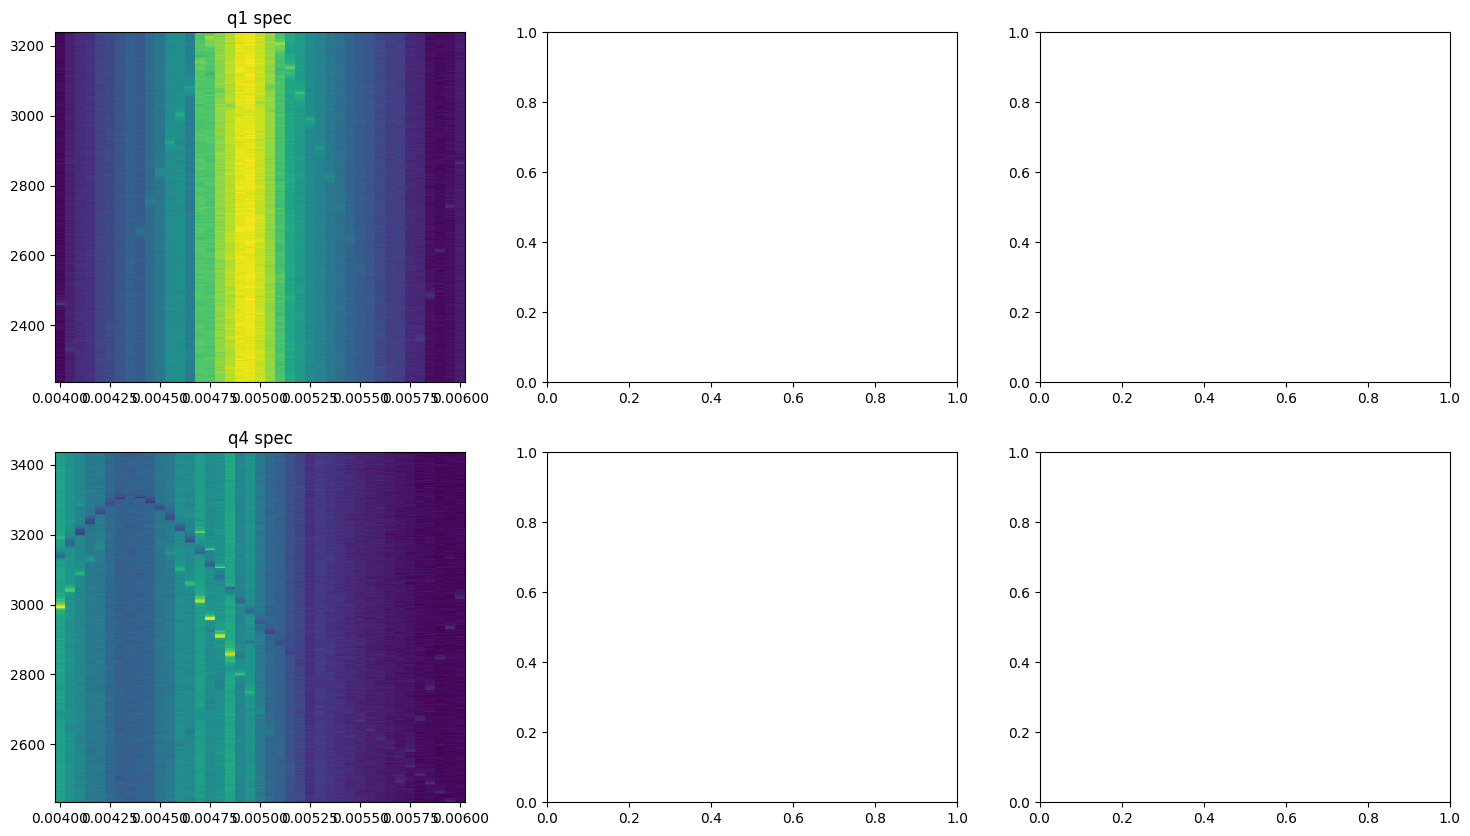

In [291]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freqs = [[]]*6
for idx in [0,3]:
    freqs[idx]= qspec.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)
axes = axes.flatten()

for i in [0,3]:
    axes[i].set_title(f'q{i+1} spec')
    axes[i].pcolormesh(flux, freqs[i], np.abs(iqlist[:,i,0].dot([1,1j])).T)

In [292]:
data_path = data_path
for i in  [0,3]:
        exp_name = f"qubit{i} flux spec"


        file_path = get_next_filename_labber(data_path, exp_name)

        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': freqs[i]*1e6},  
                y_info={'name': 'Flux', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values':  np.array(iqlist)[:, i, 0].dot([1, 1j])},
                        
                comment=f'',
                tag='TwoTone mux'
        )


# PowerRabi

In [277]:
class MuxPowerRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("gloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': QickSweep1D('gloop', 0, 1),
    'sigma':0.12
}

run_cfg = {**config, **qb_cfg}


In [278]:
prog = MuxPowerRabi(soccfg, reps=100, final_delay=150, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=50)
gains = prog.get_pulse_param('qb0_pulse', 'gain', as_array=True)

  0%|          | 0/50 [00:00<?, ?it/s]

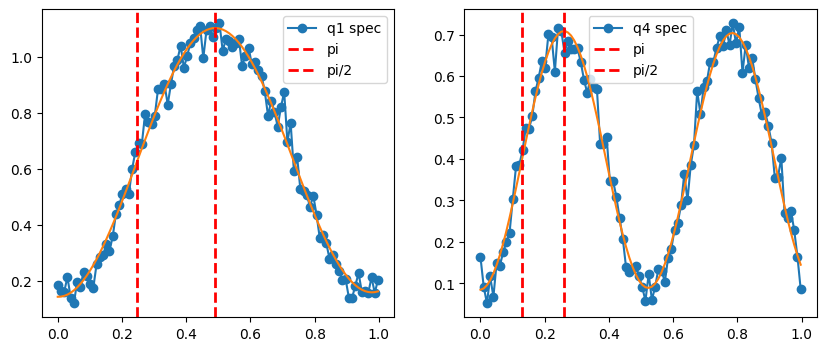

In [280]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
prabi_fit=[[]]*6
for idx, i in enumerate([0,3]):

    axes[idx].plot(gains, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} spec')

    pOpt, _ = fitdecaysin(gains,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[idx].plot(gains, decaysin(gains, *pOpt))
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[idx].axvline(pi_gain, ls='--', lw=2, color='r', label='pi')
    axes[idx].axvline(pi2_gain, ls='--', lw=2, color='r', label='pi/2')
    axes[idx].legend()
    prabi_fit[i]=([round(pi_gain,3), round(pi2_gain,3)])


# Ramsey

In [273]:
class MuxRamsey(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )

    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
            self.delay_auto(cfg['wait_time'], tag=f'wait{i}')
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)
            
        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 50
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12, 
    'wait_time': QickSweep1D('waitloop', 0, 2),
    'ramsey_freq':3
}

run_cfg = {**config, **qb_cfg}


In [274]:
prog = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=50)
delay = prog.get_time_param('wait0', "t", as_array=True)

  0%|          | 0/50 [00:00<?, ?it/s]

q1 over detune 0.185


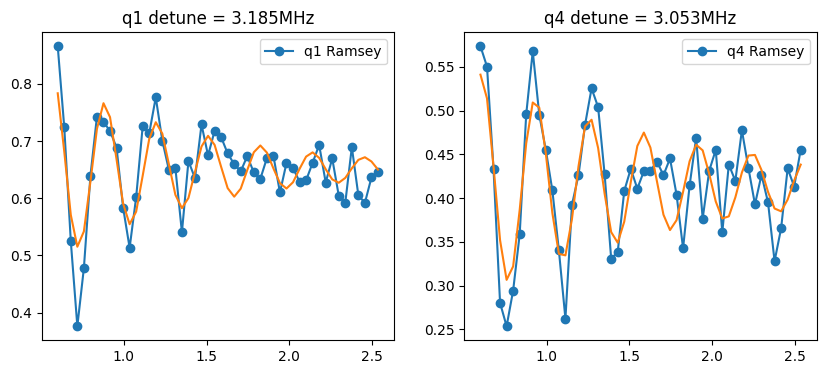

In [276]:
activate_correct=True

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} Ramsey')
    pOpt, _ = fitdecaysin(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    axes[idx].plot(delay, decaysin(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} detune = {pOpt[1]:.3f}MHz')
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[idx].legend()


    if activate_correct:
        if abs(pOpt[1]-run_cfg['ramsey_freq'])>0.1:
            f_q[i] -= round(pOpt[1]-run_cfg['ramsey_freq'],3)
            print(f'q{i+1} over detune {round((pOpt[1]-run_cfg["ramsey_freq"]),3)}')
        else:
            pass

# T1

In [282]:
class MuxT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)

        self.delay_auto(cfg['wait_time']+0.05, tag='wait')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 10,
          'ro_len': 10,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12,
    'wait_time': QickSweep1D('waitloop', 0, 200),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}


In [264]:
prog = MuxT1(soccfg, reps=10000, final_delay=200, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=1)
delay = prog.get_time_param('wait', "t", as_array=True)

  0%|          | 0/1000000 [00:00<?, ?it/s]

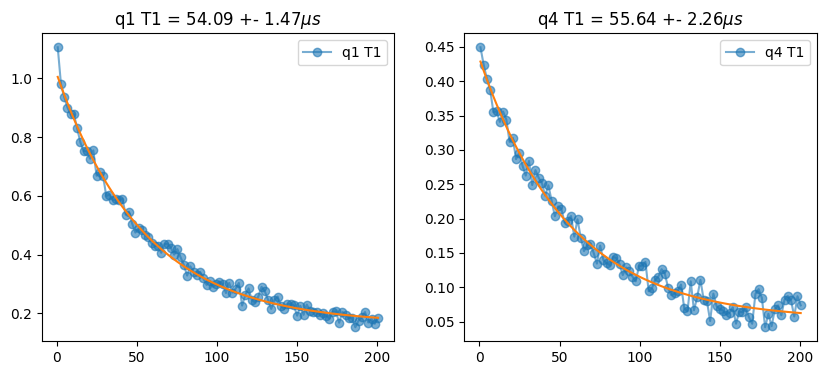

In [265]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} T1', alpha=0.6)
    pOpt, pCov = fitexp(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    p_sigma = np.sqrt(np.diag(pCov))
    axes[idx].plot(delay, expfunc(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f} +- {p_sigma[3]:.2f}$\mu s$')
    axes[idx].legend()

In [267]:
class Q4T1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):

        self.pulse(ch=cfg['qb_ch'][3], name=f"qb{3}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time']+0.05, tag='wait')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 10,
          'ro_len': 10,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12,
    'wait_time': QickSweep1D('waitloop', 0, 200),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}
prog = Q4T1(soccfg, reps=10000, final_delay=200, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=1)


  0%|          | 0/1000000 [00:00<?, ?it/s]

c:\Users\QEL\Desktop\tprocv2_guidemo-main\csutscrip\data_fitting\fitting.py:99: RuntimeWarning: overflow encountered in exp
  return y0 + yscale * np.exp(-(x - x0) / decay)


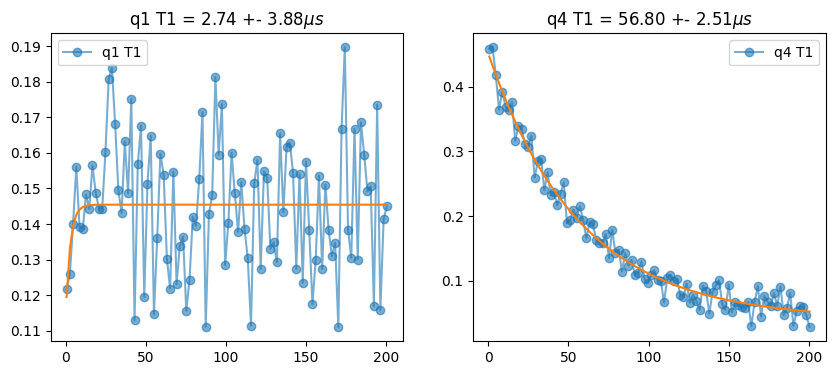

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
delay = prog.get_time_param('wait', "t", as_array=True)
for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} T1', alpha=0.6)
    pOpt, pCov = fitexp(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    p_sigma = np.sqrt(np.diag(pCov))
    axes[idx].plot(delay, expfunc(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f} +- {p_sigma[3]:.2f}$\mu s$')
    axes[idx].legend()

In [270]:
class Q1T1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        self.pulse(ch=cfg['qb_ch'][0], name=f"qb{0}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time']+0.05, tag='wait')

        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12,
    'wait_time': QickSweep1D('waitloop', 0, 200),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}

prog = Q1T1(soccfg, reps=10000, final_delay=200, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=1)
delay = prog.get_time_param('wait', "t", as_array=True)

  0%|          | 0/1000000 [00:00<?, ?it/s]

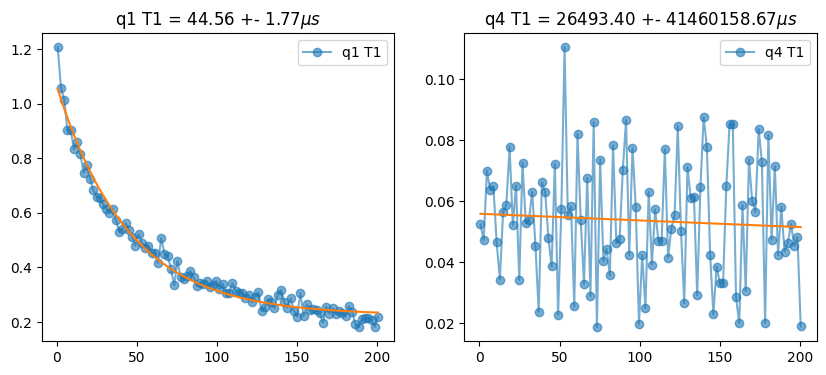

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} T1', alpha=0.6)
    pOpt, pCov = fitexp(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    p_sigma = np.sqrt(np.diag(pCov))
    axes[idx].plot(delay, expfunc(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f} +- {p_sigma[3]:.2f}$\mu s$')
    axes[idx].legend()

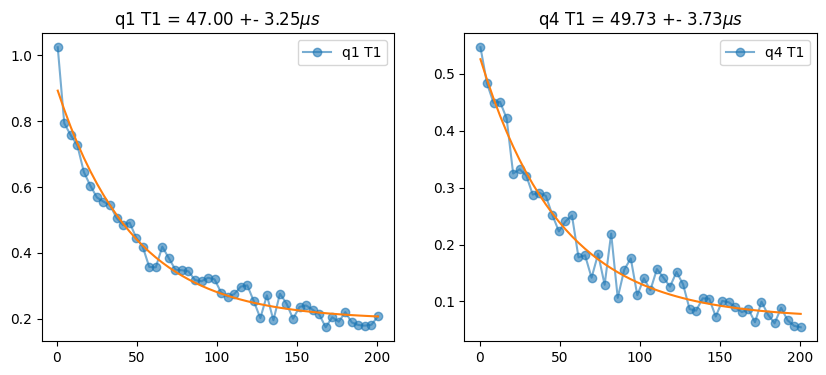

In [256]:
class Q1T1withQ4(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time'], tag='wait')
        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 70
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12,
    'wait_time': QickSweep1D('waitloop', 0, 200),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}

run_cfg['res_gains']= [0.3, 0, 0, 0.3, 0., 0.]
# prog = Q1T1withQ4(soccfg, reps=5000, final_delay=200, cfg=run_cfg)
# prog = MuxT1(soccfg, reps=5000, final_delay=200, cfg=run_cfg)
# iq_list = prog.acquire(soc, soft_avgs=1)
# delay = prog.get_time_param('wait0', "t", as_array=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} T1', alpha=0.6)
    pOpt, pCov = fitexp(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    p_sigma = np.sqrt(np.diag(pCov))
    axes[idx].plot(delay, expfunc(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f} +- {p_sigma[3]:.2f}$\mu s$')
    axes[idx].legend()

In [101]:
# try:
#         run_cfg.pop('wait_time')

# except:
#         pass
# t1config_info = yml_comment(run_cfg)
# data_path = r'C:\Users\QEL\Desktop\2DQ12\Loop'
# for i in [0,3]:
#     exp_name = f"qubit T1 q{i+1}"
#     file_path = get_next_filename_labber(data_path, exp_name)
#     hdf5_generator(
#             filepath=file_path,
#             x_info={'name': 'Times', 'unit': "s",
#                     'values': t1_delay*1e-6},
#             z_info={'name': 'Signal', 'unit': 'a.u.',
#                     'values': t1_iq_list[i][0].dot([1, 1j])},
#             comment=f'T1 = {t1config_info}',
#             tag=f'T1 q{i+1} pic'
#     )

In [283]:
import pandas as pd
import numpy as np
import time
import os

csv_filename = "interleve_5.csv"
columns = ["Timestamp", 
           "Q1 T1 (us)", "Q1 T1 sigma",
           "Q1 T4 (us)", "Q4 T1 sigma", 
           "mux Q1 T1 (us)", "muxQ1 T1 sigma",
           "mux Q4 T1 (us)", "muxQ4 T1 sigma",
           ]
reps = 10000

run_cfg['wait_time']= QickSweep1D('waitloop', 0, 100)
run_cfg['steps'] = 100
run_cfg['ro_len'] = 5
if not os.path.exists(csv_filename):
    with open(csv_filename, 'w') as f:
        f.write(",".join(columns) + "\n")

try:
    i=0
    while True:
        timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
        run_cfg['res_gains']= [0.0, 0, 0, 0.3, 0., 0.]
        prog = Q4T1(soccfg, reps=reps, final_delay=200, cfg=run_cfg)
        q4iq_list = prog.acquire(soc, soft_avgs=1, progress=False)
        delay = prog.get_time_param('wait', "t", as_array=True)
        q4t1pOpt, q4t1pCov = fitexp(delay, np.abs(q4iq_list[3][0].dot([1, 1j])))
        q4t1_sigma = np.sqrt(np.diag(q4t1pCov))

        run_cfg['res_gains']= [0.3, 0, 0, 0.0, 0., 0.]
        prog = Q1T1(soccfg, reps=reps, final_delay=200, cfg=run_cfg)
        q1iq_list = prog.acquire(soc, soft_avgs=1, progress=False)
        delay = prog.get_time_param('wait', "t", as_array=True)
        q1t1pOpt, q1t1pCov = fitexp(delay, np.abs(q1iq_list[0][0].dot([1, 1j])))
        q1t1_sigma = np.sqrt(np.diag(q1t1pCov))

        run_cfg['res_gains']= [0.3, 0, 0, 0.3, 0., 0.]
        prog = MuxT1(soccfg, reps=reps, final_delay=200, cfg=run_cfg)
        iq_list = prog.acquire(soc, soft_avgs=1, progress=False)
        delay = prog.get_time_param('wait', "t", as_array=True)
        muxq1pOpt, muxq1pCov = fitexp(delay, np.abs(iq_list[0][0].dot([1, 1j])))
        muxq1t1_sigma = np.sqrt(np.diag(muxq1pCov))
        muxq4pOpt, muxq4pCov = fitexp(delay, np.abs(iq_list[3][0].dot([1, 1j])))
        muxq4t1_sigma = np.sqrt(np.diag(muxq4pCov))

        q4t1pOpt[3], q4t1_sigma[3], q1t1pOpt[3], q1t1_sigma[3], muxq1pOpt[3], muxq1t1_sigma[3], muxq4pOpt[3], muxq4t1_sigma[3]
        with open(csv_filename, 'a') as f:
            f.write(f"{timestamp},"
                    f"{q1t1pOpt[3]:.6f},{q1t1_sigma[3]:.6f},"
                    f"{q4t1pOpt[3]:.6f},{q4t1_sigma[3]:.6f},"
                    f"{muxq1pOpt[3]:.6f},{muxq1t1_sigma[3]:.6f},"
                    f"{muxq4pOpt[3]:.6f},{muxq4t1_sigma[3]:.6f}\n")

        print(f"\r[{timestamp}] ✅ 測量完成: {i+1}次", end="", flush=True)


        img_dir = "t1_images_5"
        subfolders = ["Q1", "Q4", "muxQ1", "muxQ4"]
        for folder in subfolders:
            os.makedirs(os.path.join(img_dir, folder), exist_ok=True)

        # ...Plot and save fig...

        plt.title(f'Single Q4 T1 {q4t1pOpt[3]:.2f}us  #{i+1}')
        plt.plot(delay, np.abs(q4iq_list[3][0].dot([1, 1j])), marker='o', alpha=0.6)
        plt.plot(delay, expfunc(delay, *q4t1pOpt))
        q4_dir = os.path.join(img_dir, "MuxQ4")
        os.makedirs(q4_dir, exist_ok=True)
        plt.savefig(os.path.join(img_dir, "Q4", f"Q4_T1_{i+1}.png"))
        plt.close()

        plt.figure()
        plt.title(f'Single Q1 T1  {q1t1pOpt[3]:.2f}us #{i+1}')
        plt.plot(delay, np.abs(q1iq_list[0][0].dot([1, 1j])), marker='o', alpha=0.6)
        plt.plot(delay, expfunc(delay, *q1t1pOpt))
        q1_dir = os.path.join(img_dir, "MuxQ4")
        os.makedirs(q1_dir, exist_ok=True)
        plt.savefig(os.path.join(img_dir, "Q1", f"Q1_T1_{i+1}.png"))
        plt.close()

        plt.figure()
        plt.title(f'mux Q1 T1 {muxq1pOpt[3]:.2f}us #{i+1}')
        plt.plot(delay, np.abs(iq_list[0][0].dot([1, 1j])), marker='o', alpha=0.6)
        plt.plot(delay, expfunc(delay, *muxq1pOpt))
        muxq1_dir = os.path.join(img_dir, "MuxQ4")
        os.makedirs(muxq1_dir, exist_ok=True)
        plt.savefig(os.path.join(img_dir, "muxQ1", f"muxQ1_T1_{i+1}.png"))
        plt.close()

        plt.figure()
        plt.title(f'mux Q4 T1 {muxq4pOpt[3]:.2f}us #{i+1}')
        plt.plot(delay, np.abs(iq_list[3][0].dot([1, 1j])), marker='o', alpha=0.6)
        plt.plot(delay, expfunc(delay, *muxq4pOpt))
        muxq4_dir = os.path.join(img_dir, "MuxQ4")
        os.makedirs(muxq4_dir, exist_ok=True)
        plt.savefig(os.path.join(img_dir, "muxQ4", f"muxQ4_T1_{i+1}.png"))
        plt.close()

        i+=1

except KeyboardInterrupt:
    print("\n🔁 測量停止（使用者中斷）")
    print("✅ CSV 資料保存在：", csv_filename)

[2025-05-13 11:23:01] ✅ 測量完成: 86次
🔁 測量停止（使用者中斷）
✅ CSV 資料保存在： interleve_5.csv


# loop

In [ ]:
import pandas as pd
import numpy as np
import time
import os
from yamltool import yml_comment
# CSV 檔名與欄位

data_path = r'C:\Users\QEL\Desktop\2DQ12\Loop'
csv_filename = "Q14_T1_T2_results.csv"
columns = ["Timestamp", "Qubit", "T1 (us)", "T1 sigma", "T2 (us)", "T2 sigma"]

# 如果檔案不存在就寫入欄位標題
if not os.path.exists(csv_filename):
    with open(csv_filename, 'w') as f:
        f.write(",".join(columns) + "\n")

try:
    while True:
        for i in [0, 3]:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')

            # T1 測量
            run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 150), 'step': 70})
            t1 = MuxT1(soccfg, reps=100, final_delay=200, cfg=run_cfg)
            t1_iq_list = t1.acquire(soc, soft_avgs=50, progress=False)
            t1_delay = t1.get_time_param('wait0', "t", as_array=True)
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))

            try:
                    run_cfg.pop('wait_time')

            except:
                    pass
            t1config_info = yml_comment(run_cfg)
            exp_name = f"qubit T1 q{i+1}"
            file_path = get_next_filename_labber(data_path, exp_name)
            hdf5_generator(
                    filepath=file_path,
                    x_info={'name': 'Times', 'unit': "s",
                            'values': t1_delay*1e-6},
                    z_info={'name': 'Signal', 'unit': 'a.u.',
                            'values': t1_iq_list[i][0].dot([1, 1j])},
                    comment=f'T1 = {round(t1pOpt[3],3)} ± {round(t1_sigma[3],3)} us\
                        \n{t1config_info}',
                    tag=f'T1 q{i+1}'
            )

            # T2 測量
            run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 2), 'step': 50, 'ramsey_freq':2})
            t2 = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)
            t2_iq_list = t2.acquire(soc, soft_avgs=100, progress=False)
            t2_delay = t2.get_time_param('wait0', "t", as_array=True)
            t2pOpt, t2pCov = fitdecaysin(t2_delay, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))

            try:
                    run_cfg.pop('wait_time')

            except:
                    pass
            t2config_info = yml_comment(run_cfg)

            exp_name = f"qubit T2R q{idx+1}"
            file_path = get_next_filename_labber(data_path, exp_name)
            hdf5_generator(
                    filepath=file_path,
                    x_info={'name': 'Times', 'unit': "s",
                            'values': t2_delay*1e-6},
                    z_info={'name': 'Signal', 'unit': 'a.u.',
                            'values': t2_iq_list[i][0].dot([1, 1j])},
                    comment=f'T2 = {round(t2pOpt[3],3)} ±{round(t2_sigma[3],3)} us\
                        \n{t2config_info}',
                    tag=f'T2R q{i+1}'
            )

            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1pOpt[3]:.6f},{t1_sigma[3]:.6f},{t2pOpt[3]:.6f},{t2_sigma[3]:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1pOpt[3]:.3f} ± {t1_sigma[3]:.3f} μs, T2 = {t2pOpt[3]:.3f} ± {t2_sigma[3]:.3f} μs")

except KeyboardInterrupt:
    print("\n🔁 測量停止（使用者中斷）")
    print("✅ CSV 資料保存在：", csv_filename)

[2025-05-09 00:49:34] ✅ Qubit1 測量完成: T1 = 22.551 ± 1.391 μs, T2 = 1.204 ± 0.267 μs
[2025-05-09 00:52:58] ✅ Qubit4 測量完成: T1 = 52.044 ± 3.666 μs, T2 = 1.259 ± 0.231 μs
[2025-05-09 00:56:22] ✅ Qubit1 測量完成: T1 = 21.989 ± 1.071 μs, T2 = 1.113 ± 0.201 μs
[2025-05-09 00:59:46] ✅ Qubit4 測量完成: T1 = 44.811 ± 2.895 μs, T2 = 1.101 ± 0.237 μs
[2025-05-09 01:03:10] ✅ Qubit1 測量完成: T1 = 20.179 ± 1.037 μs, T2 = 0.992 ± 0.212 μs
[2025-05-09 01:06:34] ✅ Qubit4 測量完成: T1 = 53.651 ± 3.815 μs, T2 = 1.264 ± 0.278 μs
[2025-05-09 01:09:58] ✅ Qubit1 測量完成: T1 = 21.778 ± 1.070 μs, T2 = 0.984 ± 0.202 μs
[2025-05-09 01:13:22] ✅ Qubit4 測量完成: T1 = 50.135 ± 2.751 μs, T2 = 1.170 ± 0.203 μs

🔁 測量停止（使用者中斷）
✅ CSV 資料保存在： Q14_T1_T2_results.csv


In [ ]:
import pandas as pd
import numpy as np
import time
import os
from yamltool import yml_comment
# CSV 檔名與欄位

data_path = r'C:\Users\QEL\Desktop\2DQ12\Loop'
csv_filename = "Q14_T1_T2_results_2.csv"
columns = ["Timestamp", "Qubit", "T1 (us)", "T1 sigma", "T2 (us)", "T2 sigma"]

# 如果檔案不存在就寫入欄位標題
if not os.path.exists(csv_filename):
    with open(csv_filename, 'w') as f:
        f.write(",".join(columns) + "\n")

try:
    while True:

        # T1 測量
        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 150), 'step': 70})
        t1 = MuxT1(soccfg, reps=100, final_delay=200, cfg=run_cfg)
        t1_iq_list = t1.acquire(soc, soft_avgs=50, progress=False)
        t1_delay = t1.get_time_param('wait0', "t", as_array=True)

        # T2 測量
        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 2), 'step': 50, 'ramsey_freq':2})
        t2 = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)
        t2_iq_list = t2.acquire(soc, soft_avgs=100, progress=False)
        t2_delay = t2.get_time_param('wait0', "t", as_array=True)

        for i in [0, 3]:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))
            try:
                    run_cfg.pop('wait_time')

            except:
                    pass
            t1config_info = yml_comment(run_cfg)
            exp_name = f"qubit T1 q{i+1}"
            file_path = get_next_filename_labber(data_path, exp_name)
            hdf5_generator(
                    filepath=file_path,
                    x_info={'name': 'Times', 'unit': "s",
                            'values': t1_delay*1e-6},
                    z_info={'name': 'Signal', 'unit': 'a.u.',
                            'values': t1_iq_list[i][0].dot([1, 1j])},
                    comment=f'T1 = {round(t1pOpt[3],3)} ± {round(t1_sigma[3],3)} us\
                        \n{t1config_info}',
                    tag=f'T1 q{i+1}_2'
            )

            t2pOpt, t2pCov = fitdecaysin(t2_delay, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))
            try:
                    run_cfg.pop('wait_time')

            except:
                    pass
            t2config_info = yml_comment(run_cfg)

            exp_name = f"qubit T2R q{idx+1}"
            file_path = get_next_filename_labber(data_path, exp_name)
            hdf5_generator(
                    filepath=file_path,
                    x_info={'name': 'Times', 'unit': "s",
                            'values': t2_delay*1e-6},
                    z_info={'name': 'Signal', 'unit': 'a.u.',
                            'values': t2_iq_list[i][0].dot([1, 1j])},
                    comment=f'T2 = {round(t2pOpt[3],3)} ±{round(t2_sigma[3],3)} us\
                        \n{t2config_info}',
                    tag=f'T2R q{i+1}_2'
            )

            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1pOpt[3]:.6f},{t1_sigma[3]:.6f},{t2pOpt[3]:.6f},{t2_sigma[3]:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1pOpt[3]:.3f} ± {t1_sigma[3]:.3f} μs, T2 = {t2pOpt[3]:.3f} ± {t2_sigma[3]:.3f} μs")

except KeyboardInterrupt:
    print("\n🔁 測量停止（使用者中斷）")
    print("✅ CSV 資料保存在：", csv_filename)

[2025-05-09 01:26:14] ✅ Qubit1 測量完成: T1 = 22.274 ± 0.955 μs, T2 = 0.977 ± 0.181 μs
[2025-05-09 01:26:14] ✅ Qubit4 測量完成: T1 = 51.737 ± 3.557 μs, T2 = 1.112 ± 0.178 μs
[2025-05-09 01:29:38] ✅ Qubit1 測量完成: T1 = 22.328 ± 1.351 μs, T2 = 0.995 ± 0.193 μs
[2025-05-09 01:29:39] ✅ Qubit4 測量完成: T1 = 54.326 ± 4.242 μs, T2 = 1.291 ± 0.259 μs
[2025-05-09 01:33:03] ✅ Qubit1 測量完成: T1 = 24.715 ± 1.673 μs, T2 = 1.092 ± 0.336 μs
[2025-05-09 01:33:03] ✅ Qubit4 測量完成: T1 = 51.439 ± 3.427 μs, T2 = 1.263 ± 0.242 μs
[2025-05-09 01:36:27] ✅ Qubit1 測量完成: T1 = 23.906 ± 1.345 μs, T2 = 0.992 ± 0.187 μs
[2025-05-09 01:36:27] ✅ Qubit4 測量完成: T1 = 47.711 ± 3.069 μs, T2 = 1.214 ± 0.227 μs
[2025-05-09 01:39:51] ✅ Qubit1 測量完成: T1 = 22.324 ± 1.189 μs, T2 = 0.931 ± 0.151 μs
[2025-05-09 01:39:51] ✅ Qubit4 測量完成: T1 = 55.752 ± 3.957 μs, T2 = 1.195 ± 0.237 μs
[2025-05-09 01:43:15] ✅ Qubit1 測量完成: T1 = 24.426 ± 1.095 μs, T2 = 1.012 ± 0.223 μs
[2025-05-09 01:43:15] ✅ Qubit4 測量完成: T1 = 54.651 ± 3.523 μs, T2 = 1.048 ± 0.195 μs
[202